# INTRODUCCION

El objetivo de esta actividad es desarrollar una red neuronal convolucional (CNN) utilizando Keras para clasificar imágenes de personajes de Los Simpson. El desafío principal radica en la complejidad del conjunto de datos, que presenta variaciones en las poses, posiciones y la presencia de otros personajes en las imágenes.

Para lograr este objetivo, exploraremos diversas arquitecturas de CNN, ajustaremos hiperparámetros como el optimizador, la profundidad de la red y las técnicas de regularización, como el batch normalization y el dropout. Además, evaluaremos la efectividad de la normalización de datos y la división del conjunto de datos en entrenamiento y validación para prevenir el sobreajuste. También realizaremos un análisis detallado de los resultados, incluyendo métricas por clase, para identificar qué personajes o tipos de imágenes presentan mayores desafíos para el modelo. Finalmente, se presentará el entrenamiento completo y la evaluación del mejor modelo obtenido.

In [ ]:
from tensorflow import keras
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
import os
import cv2
import glob
import pandas as pd
from sklearn.metrics import classification_report

In [ ]:
url_test ='https://drive.google.com/file/d/1sBPC9sBFKuJeDLytbD7Bk3G-qqWAOKuk/view?usp=sharing'
url_train = 'https://drive.google.com/file/d/1K9vcvLxIFBv2NvY0MCAIUsmZUT6zuR7l/view?usp=sharing'

!gdown --fuzzy $url_train
!gdown --fuzzy $url_test

!tar -xzf /content/simpsons_train.tar.gz -C /content/
!tar -xzf /content/simpsons_test.tar.gz -C /content/

Downloading...
From (original): https://drive.google.com/uc?id=1K9vcvLxIFBv2NvY0MCAIUsmZUT6zuR7l
From (redirected): https://drive.google.com/uc?id=1K9vcvLxIFBv2NvY0MCAIUsmZUT6zuR7l&confirm=t&uuid=39a4b0cc-0e47-4887-8ba1-18166c952887
To: /content/simpsons_train.tar.gz
100% 524M/524M [00:08<00:00, 63.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1sBPC9sBFKuJeDLytbD7Bk3G-qqWAOKuk
To: /content/simpsons_test.tar.gz
100% 10.7M/10.7M [00:00<00:00, 145MB/s]


In [ ]:
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Vamos a standarizar todas las imágenes a tamaño 64x64
IMG_SIZE = 96

# CARGA DE LOS DATOS

In [ ]:
def load_train_set(dirname, map_characters, verbose=True):
    """Esta función carga los datos de training en imágenes.

    Como las imágenes tienen tamaños distintas, utilizamos la librería opencv
    para hacer un resize y adaptarlas todas a tamaño IMG_SIZE x IMG_SIZE.

    Args:
        dirname: directorio completo del que leer los datos
        map_characters: variable de mapeo entre labels y personajes
        verbose: si es True, muestra información de las imágenes cargadas

    Returns:
        X, y: X es un array con todas las imágenes cargadas con tamaño
                IMG_SIZE x IMG_SIZE
              y es un array con las labels de correspondientes a cada imagen
    """
    X_train = []
    y_train = []
    for label, character in map_characters.items():
        files = os.listdir(os.path.join(dirname, character))
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
            print("Leyendo {} imágenes encontradas de {}".format(len(images), character))
        for image_name in images:
            image_path = os.path.join(dirname, character, image_name)
            image = cv2.imread(image_path)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # ← Conversión aquí
            X_train.append(image)
            y_train.append(label)
    return np.array(X_train), np.array(y_train)

In [ ]:
def load_test_set(dirname, map_characters, verbose=True):
    """Esta función funciona de manera equivalente a la función load_train_set
    pero cargando los datos de test."""
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)


In [ ]:
DATASET_TRAIN_PATH_COLAB = "/content/simpsons"
DATASET_TEST_PATH_COLAB = "/content/simpsons_testset"

X_train, y_train = load_train_set(DATASET_TRAIN_PATH_COLAB, MAP_CHARACTERS)
X_test, y_test = load_test_set(DATASET_TEST_PATH_COLAB, MAP_CHARACTERS)

Leyendo 913 imágenes encontradas de abraham_grampa_simpson
Leyendo 623 imágenes encontradas de apu_nahasapeemapetilon
Leyendo 1342 imágenes encontradas de bart_simpson
Leyendo 1193 imágenes encontradas de charles_montgomery_burns
Leyendo 986 imágenes encontradas de chief_wiggum
Leyendo 469 imágenes encontradas de comic_book_guy
Leyendo 457 imágenes encontradas de edna_krabappel
Leyendo 2246 imágenes encontradas de homer_simpson
Leyendo 498 imágenes encontradas de kent_brockman
Leyendo 1206 imágenes encontradas de krusty_the_clown
Leyendo 1354 imágenes encontradas de lisa_simpson
Leyendo 1291 imágenes encontradas de marge_simpson
Leyendo 1079 imágenes encontradas de milhouse_van_houten
Leyendo 1452 imágenes encontradas de moe_szyslak
Leyendo 1454 imágenes encontradas de ned_flanders
Leyendo 358 imágenes encontradas de nelson_muntz
Leyendo 1194 imágenes encontradas de principal_skinner
Leyendo 877 imágenes encontradas de sideshow_bob
Leídas 890 imágenes de test


In [ ]:
total = (X_train.shape[0] + X_test.shape[0])
print(total)
porcentaje = (X_test.shape[0] / total) * 100
print(porcentaje)

19882
4.476410823860778


In [ ]:
# Vamos a barajar aleatoriamente los datos. Esto es importante ya que si no
# lo hacemos y, por ejemplo, cogemos el 20% de los datos finales como validation
# set, estaremos utilizando solo un pequeño número de personajes, ya que
# las imágenes se leen secuencialmente personaje a personaje.
perm = np.random.permutation(len(X_train))
X_train, y_train = X_train[perm], y_train[perm]

In [ ]:
CHARACTERS_NAMES = [
    'abraham_grampa_simpson','apu_nahasapeemapetilon','bart_simpson',
    'charles_montgomery_burns','chief_wiggum','comic_book_guy','edna_krabappel',
    'homer_simpson', 'kent_brockman', 'krusty_the_clown', 'lisa_simpson',
    'marge_simpson', 'milhouse_van_houten', 'moe_szyslak',
    'ned_flanders', 'nelson_muntz', 'principal_skinner', 'sideshow_bob'
]

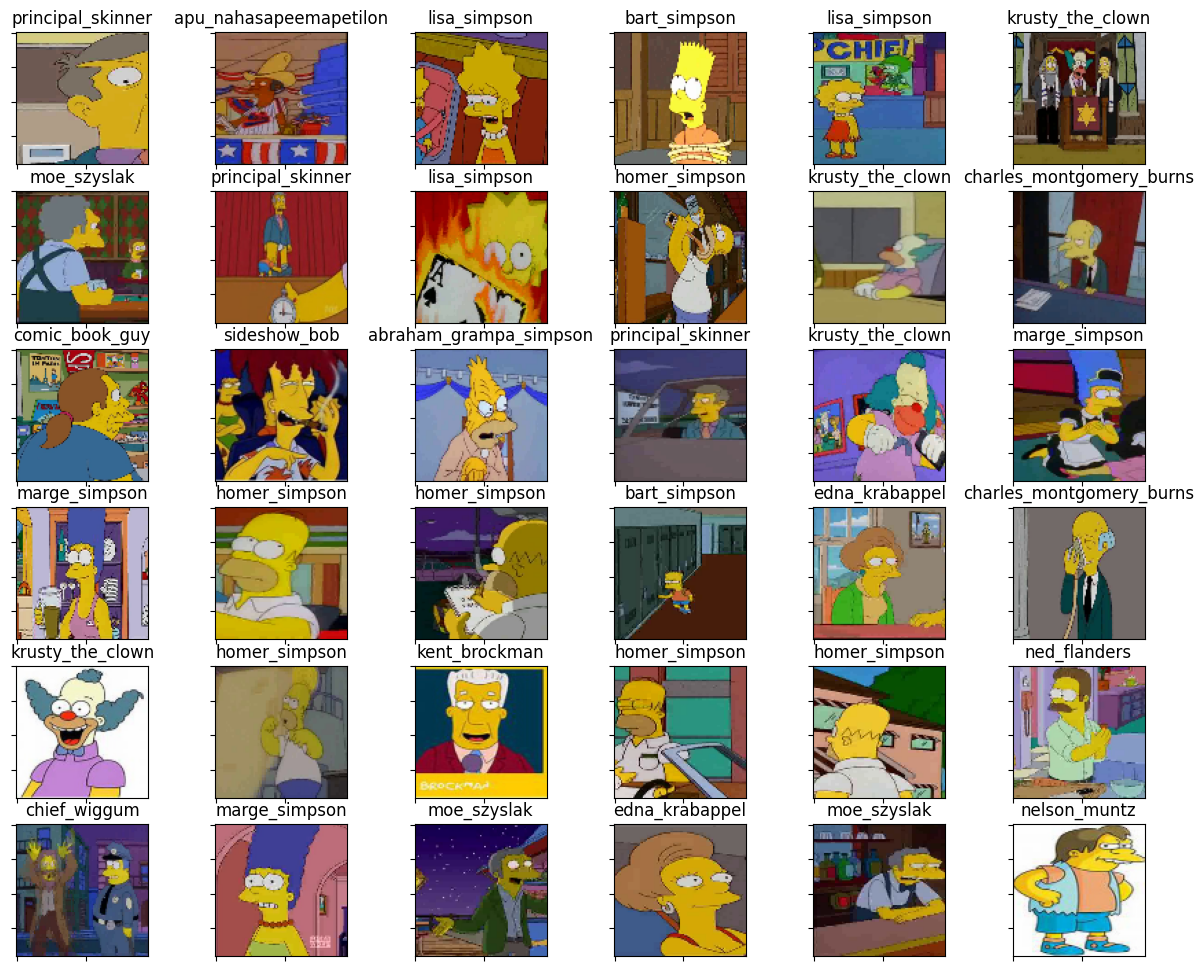

In [ ]:
h = 6 # alto de la grilla
w = 6 # ancho de la grilla
fig, axs = plt.subplots(h, w, figsize=(2.5*h,2*w))
for i in range(h):
  for j in range(w):
    ex = np.random.randint(len(X_train))
    axs[i,j].set_title(CHARACTERS_NAMES[y_train[ex]])
    axs[i,j].grid(False)
    axs[i,j].set_xticklabels([])
    axs[i,j].set_yticklabels([])
    axs[i,j].imshow(X_train[ex])

In [ ]:
from re import X
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

def augment_underrepresented_classes(X_train, y_train, target_samples=1000):
    """
    Aumenta las clases con menos de `target_samples` usando ImageDataGenerator.

    Args:
        X_train: np.array de imágenes (RGB, valores 0-255).
        y_train: np.array de etiquetas enteras.
        target_samples: número objetivo de muestras por clase.

    Returns:
        X_augmented, y_augmented: arrays aumentados, normalizados a [0,1].
    """
    X_augmented = []
    y_augmented = []

    datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Conteo actual de clases
    class_labels = np.unique(y_train)
    for class_label in class_labels:
        idxs = np.where(y_train == class_label)[0]
        X_class = X_train[idxs]
        y_class = y_train[idxs]
        num_samples = len(idxs)

        # Normaliza para el generador
        X_class_norm = X_class.astype('float32') / 255.0

        if num_samples < target_samples:
            num_to_generate = target_samples - num_samples
            generator = datagen.flow(X_class_norm, y_class, batch_size=32)

            gen_images = []
            gen_labels = []
            for _ in range((num_to_generate // 32) + 1):
                imgs, labels = next(generator)
                gen_images.append(imgs)
                gen_labels.append(labels)

            X_gen = np.vstack(gen_images)[:num_to_generate]
            y_gen = np.hstack(gen_labels)[:num_to_generate]

            # Agrega originales + generadas
            X_augmented.append(X_class_norm)
            y_augmented.append(y_class)
            X_augmented.append(X_gen)
            y_augmented.append(y_gen)
        else:
            # Solo agrega las originales, normalizadas
            X_augmented.append(X_class.astype('float32') / 255.0)
            y_augmented.append(y_class)

    # Combina todo en un solo array
    X_final = np.vstack(X_augmented)
    y_final = np.hstack(y_augmented)

    return X_final, y_final

X_final, y_final = augment_underrepresented_classes(X_train, y_train, target_samples=1000)


In [ ]:
# prompt: quiero que cuentes la cantidad de muestras por clase que hay en la variable y_final

from collections import Counter

# Count the occurrences of each class label in y_final
class_counts = Counter(y_final)

# Print the class counts
for class_label, count in class_counts.items():
    print(f"Class {class_label}: {count} samples")


Class 0: 1000 samples
Class 1: 1000 samples
Class 2: 1342 samples
Class 3: 1193 samples
Class 4: 1000 samples
Class 5: 1000 samples
Class 6: 978 samples
Class 7: 2246 samples
Class 8: 996 samples
Class 9: 1206 samples
Class 10: 1354 samples
Class 11: 1291 samples
Class 12: 1079 samples
Class 13: 1452 samples
Class 14: 1454 samples
Class 15: 1000 samples
Class 16: 1194 samples
Class 17: 1000 samples


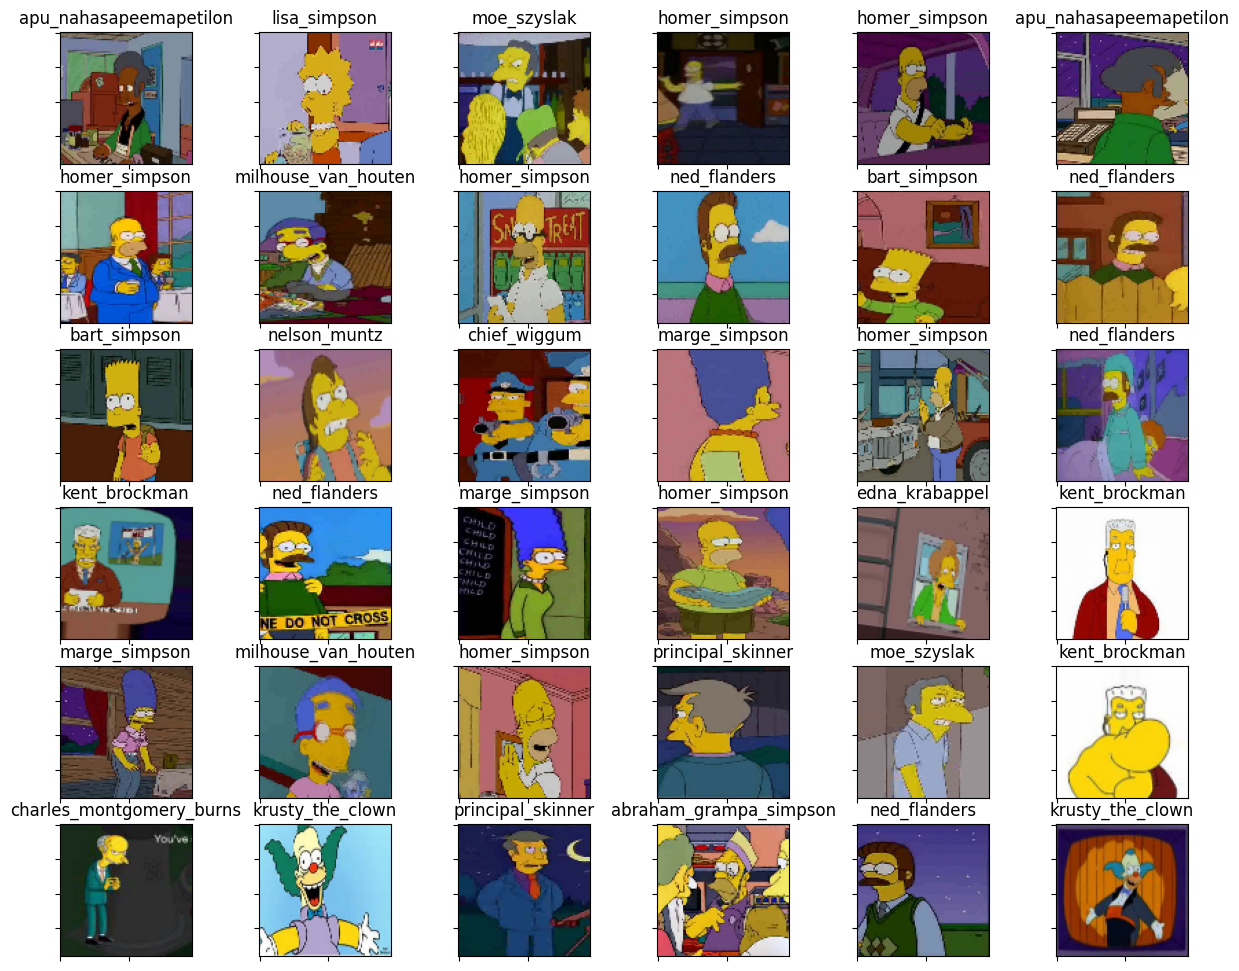

In [ ]:
h = 6 # alto de la grilla
w = 6 # ancho de la grilla
fig, axs = plt.subplots(h, w, figsize=(2.5*h,2*w))
for i in range(h):
  for j in range(w):
    ex = np.random.randint(len(X_final))
    axs[i,j].set_title(CHARACTERS_NAMES[y_final[ex]])
    axs[i,j].grid(False)
    axs[i,j].set_xticklabels([])
    axs[i,j].set_yticklabels([])
    axs[i,j].imshow(X_final[ex])

In [ ]:
# 1. Normalizás las imágenes
X = X_final

# 2. Split de datos crudos
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_final, test_size=0.3)

# 3. One-hot encoding de etiquetas
y_train = keras.utils.to_categorical(y_train, num_classes=18)
y_test = keras.utils.to_categorical(y_test, num_classes=18)


## Primera Red (AlexNet)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

red_conv = keras.Sequential()
# Bloque 1
red_conv.add(Conv2D(96, activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3), padding='valid',kernel_size=(11,11), strides= 4, kernel_initializer= 'he_normal'))

red_conv.add(MaxPooling2D(pool_size=(2,2), strides= (2,2),
                              padding= 'valid', data_format= None))


# Bloque 2
red_conv.add(Conv2D(256, kernel_size=(5,5), strides= 1,
                        padding= 'same', activation= 'relu',
                        kernel_initializer= 'he_normal'))

red_conv.add(MaxPooling2D(pool_size=(2,2), strides= (2,2),
                              padding= 'valid', data_format= None))

# Bloque 3
red_conv.add(Conv2D(384, kernel_size=(3,3), strides= 1,
                        padding= 'same', activation= 'relu',
                        kernel_initializer= 'he_normal'))
red_conv.add(Conv2D(384, kernel_size=(3,3), strides= 1,
                        padding= 'same', activation= 'relu',
                        kernel_initializer= 'he_normal'))
red_conv.add(Conv2D(256, kernel_size=(3,3), strides= 1,
                        padding= 'same', activation= 'relu',
                        kernel_initializer= 'he_normal'))
red_conv.add(MaxPooling2D(pool_size=(2,2), strides= (2,2),
                              padding= 'valid', data_format= None))

# Clasificador
red_conv.add(Flatten())
red_conv.add(Dense(4096, activation= 'relu'))
red_conv.add(Dense(4096, activation= 'relu'))
red_conv.add(Dense(1000, activation= 'relu'))
red_conv.add(Dense(18, activation= 'softmax'))

red_conv.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 22, 22, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 5, 5, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 5, 5, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 5, 5, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1000)           │     4,097,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 18)             │        18,018 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,841,930 (110.02 MB)

 Trainable params: 28,841,930 (110.02 MB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

In [ ]:
import datetime
log_dir="./logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
callback_list = [tensorboard_callback]
red_conv.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=['accuracy'],
)

hist = red_conv.fit(
    X_train,y_train,
    batch_size=32,
    epochs=25,
    validation_data=(X_test,y_test),
    callbacks=callback_list
)

Epoch 1/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.0974 - loss: 3.3149 - val_accuracy: 0.1001 - val_loss: 2.8671
Epoch 2/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - accuracy: 0.1033 - loss: 2.8671 - val_accuracy: 0.1001 - val_loss: 2.8665
Epoch 3/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.1073 - loss: 2.8968 - val_accuracy: 0.1001 - val_loss: 2.8658
Epoch 4/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.1046 - loss: 2.8647 - val_accuracy: 0.1001 - val_loss: 2.8664
Epoch 5/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.1018 - loss: 2.8629 - val_accuracy: 0.1001 - val_loss: 2.8659
Epoch 6/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.1082 - loss: 2.8626 - val_accuracy: 0.1001 - val_loss: 2.8664
Epoch 7/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.1083 - loss: 2.8605 - val_accuracy: 0.1001 - val_loss: 2.8666
Epoch 8/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.1040 - loss: 2.8644 - 

### Evaluacion del modelo

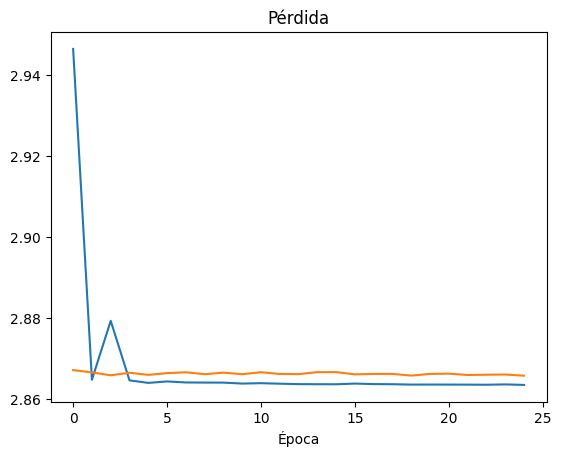

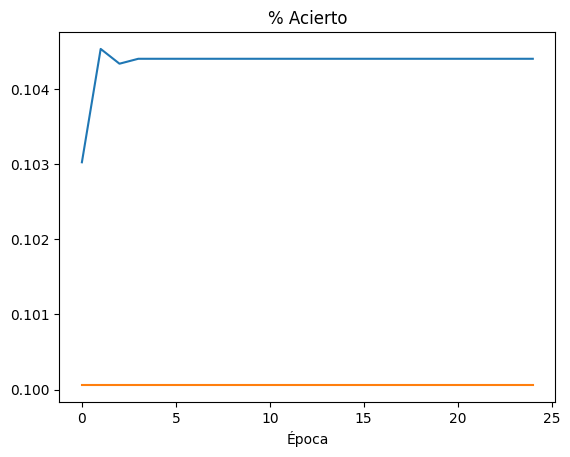

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

In [ ]:
report_dict = classification_report(y_test.argmax(axis=1), red_conv.predict(X_test).argmax(axis=1), target_names=CHARACTERS_NAMES)

205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print (report_dict)

                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.00      0.00      0.00       289
  apu_nahasapeemapetilon       0.00      0.00      0.00       290
            bart_simpson       0.00      0.00      0.00       403
charles_montgomery_burns       0.00      0.00      0.00       340
            chief_wiggum       0.00      0.00      0.00       298
          comic_book_guy       0.00      0.00      0.00       309
          edna_krabappel       0.00      0.00      0.00       294
           homer_simpson       0.10      1.00      0.18       654
           kent_brockman       0.00      0.00      0.00       296
        krusty_the_clown       0.00      0.00      0.00       364
            lisa_simpson       0.00      0.00      0.00       434
           marge_simpson       0.00      0.00      0.00       383
     milhouse_van_houten       0.00      0.00      0.00       328
             moe_szyslak       0.00      0.00      0.00       435
         

## Segunda Red (ResNet)

In [ ]:
from tensorflow.keras import layers, models, Input
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, Add, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.regularizers import l2

def residual_block(x, filters, stride=1, downsample=False):
    shortcut = x

    # Primer conv
    x = Conv2D(filters, kernel_size=3, strides=stride, padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Segundo conv
    x = Conv2D(filters, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)

    # Atajo (shortcut)
    if downsample:
        shortcut = Conv2D(filters, kernel_size=1, strides=stride, padding='same', kernel_initializer='he_normal')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x

# Entrada
inputs = Input(shape=(IMG_SIZE,IMG_SIZE, 3))
x = Conv2D(64, kernel_size=7, strides=2, padding='same', kernel_initializer='he_normal')(inputs)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

# Bloques residuales
x = residual_block(x, 64)
x = residual_block(x, 64)

x = residual_block(x, 128, stride=2, downsample=True)
x = residual_block(x, 128)

x = residual_block(x, 256, stride=2, downsample=True)
x = residual_block(x, 256)

x = residual_block(x, 512, stride=2, downsample=True)
x = residual_block(x, 512)

# Clasificación mejorada
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.5)(x)
outputs = Dense(18, activation='softmax')(x)

# Modelo
resnet_model = models.Model(inputs, outputs)
resnet_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 48, 48,    │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48, 48,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 24, 24,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 24, 24,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 24, 24,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 24,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 24, 24,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 24, 24,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 24, 24,    │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        256 │ conv2d_4[0][0]  

 Total params: 11,589,522 (44.21 MB)

 Trainable params: 11,579,922 (44.17 MB)

 Non-trainable params: 9,600 (37.50 KB)

### Entrenamiento

In [ ]:
from keras.optimizers import Adam


resnet_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1)

callbacks = [early_stop, reduce_lr]

hist = resnet_model.fit(
    X_train,y_train,
    batch_size=64,
    epochs=25,
    validation_data=(X_test,y_test),
    callbacks=callbacks
)

Epoch 1/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 66s 137ms/step - accuracy: 0.1312 - loss: 2.9228 - val_accuracy: 0.2301 - val_loss: 3.0056 - learning_rate: 0.0010
Epoch 2/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.4213 - loss: 1.8789 - val_accuracy: 0.3236 - val_loss: 2.9758 - learning_rate: 0.0010
Epoch 3/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.5778 - loss: 1.3590 - val_accuracy: 0.6013 - val_loss: 1.5021 - learning_rate: 0.0010
Epoch 4/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.7001 - loss: 1.0108 - val_accuracy: 0.7151 - val_loss: 1.0703 - learning_rate: 0.0010
Epoch 5/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.7677 - loss: 0.7959 - val_accuracy: 0.4691 - val_loss: 2.4639 - learning_rate: 0.0010
Epoch 6/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.8062 - loss: 0.7180 - val_accuracy: 0.4894 - val_loss: 2.9875 - learning_rate: 0.0010
Epoch 7/25
238/239 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8325 - l

### Evaluacion del modelo

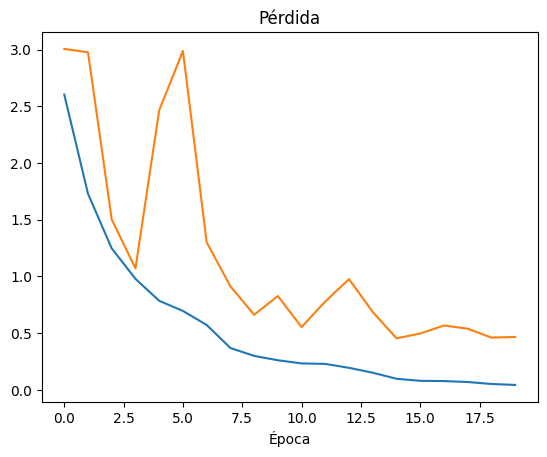

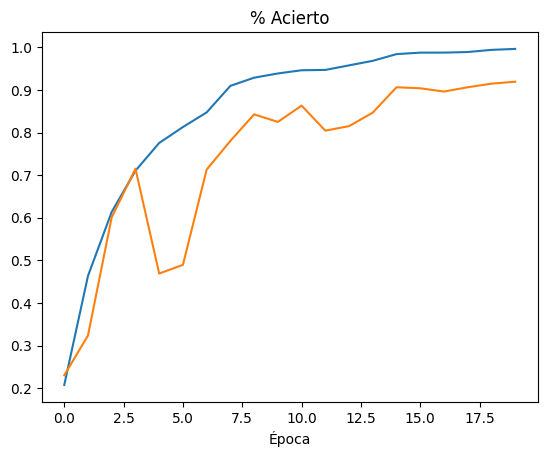

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

In [ ]:
report_dict = classification_report(y_test.argmax(axis=1), resnet_model.predict(X_test).argmax(axis=1), target_names=CHARACTERS_NAMES)

205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step


In [ ]:
print (report_dict)

                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.91      0.87      0.89       312
  apu_nahasapeemapetilon       0.99      0.94      0.96       306
            bart_simpson       0.82      0.89      0.85       396
charles_montgomery_burns       0.89      0.82      0.85       377
            chief_wiggum       0.94      0.90      0.92       292
          comic_book_guy       0.85      0.83      0.84       278
          edna_krabappel       0.95      0.88      0.91       276
           homer_simpson       0.85      0.92      0.89       651
           kent_brockman       0.94      0.95      0.94       316
        krusty_the_clown       0.94      0.96      0.95       352
            lisa_simpson       0.90      0.85      0.87       369
           marge_simpson       0.96      0.95      0.95       369
     milhouse_van_houten       0.93      0.95      0.94       356
             moe_szyslak       0.92      0.87      0.89       471
         

## Tercera Red (Inception V3)

In [ ]:
import tensorflow as tf

num_classes = 18  # cambia al número de clases que tengas

# Carga el modelo base InceptionV3 sin la capa final (sin "top")
base_model = tf.keras.applications.InceptionV3(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Congelamos las capas base para no entrenarlas al principio (opcional)
base_model.trainable = True

# Creamos la parte superior (clasificador)
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)          # salida del backbone
x = tf.keras.layers.GlobalAveragePooling2D()(x)  # pool global
x = tf.keras.layers.Dropout(0.2)(x)             # regularización
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# Compilamos
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.00001),
    loss='categorical_crossentropy',  # o 'categorical_crossentropy' si etiquetas one-hot
    metrics=['accuracy']
)

model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 1, 1, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 18)             │        36,882 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,839,666 (83.31 MB)

 Trainable params: 21,805,234 (83.18 MB)

 Non-trainable params: 34,432 (134.50 KB)

### Entrenamiento

In [ ]:
hist = model.fit(
    X_train,y_train,
    batch_size=64,
    epochs=25,
    validation_data=(X_test,y_test)
)

Epoch 1/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 154s 292ms/step - accuracy: 0.0607 - loss: 2.9878 - val_accuracy: 0.1105 - val_loss: 2.8522
Epoch 2/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step - accuracy: 0.1228 - loss: 2.8161 - val_accuracy: 0.1830 - val_loss: 2.7428
Epoch 3/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.2103 - loss: 2.6318 - val_accuracy: 0.2841 - val_loss: 2.4957
Epoch 4/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.3178 - loss: 2.3447 - val_accuracy: 0.3955 - val_loss: 2.1508
Epoch 5/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 22s 91ms/step - accuracy: 0.4454 - loss: 1.9864 - val_accuracy: 0.4930 - val_loss: 1.8491
Epoch 6/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.5393 - loss: 1.6794 - val_accuracy: 0.5632 - val_loss: 1.6132
Epoch 7/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.6163 - loss: 1.4133 - val_accuracy: 0.6069 - val_loss: 1.4410
Epoch 8/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.6709 - loss: 1.2099 

### Evaluacion del modelo

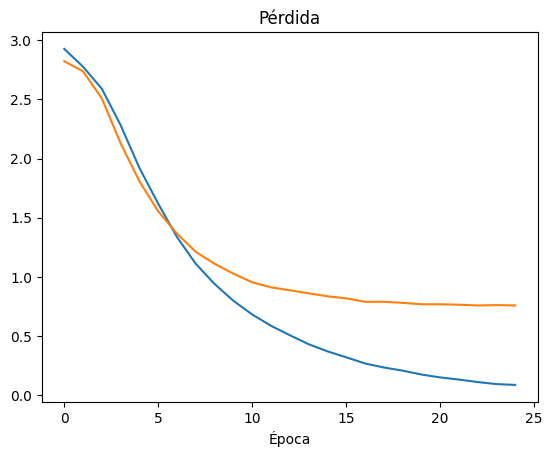

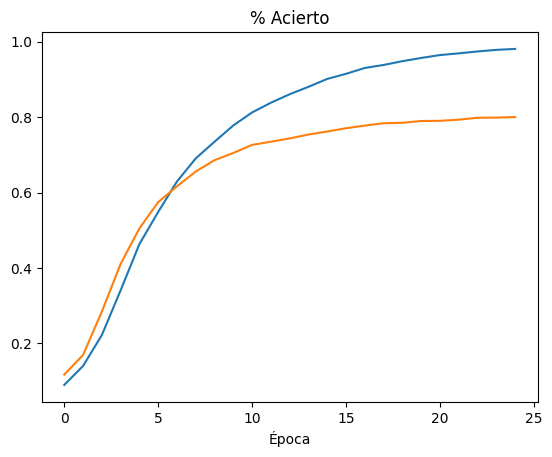

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

In [ ]:
report_dict = classification_report(y_test.argmax(axis=1), model.predict(X_test).argmax(axis=1), target_names=CHARACTERS_NAMES)

205/205 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step


In [ ]:
print (report_dict)

                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.81      0.78      0.80       287
  apu_nahasapeemapetilon       0.83      0.82      0.83       288
            bart_simpson       0.84      0.82      0.83       415
charles_montgomery_burns       0.78      0.77      0.77       362
            chief_wiggum       0.78      0.85      0.81       294
          comic_book_guy       0.71      0.71      0.71       306
          edna_krabappel       0.73      0.71      0.72       290
           homer_simpson       0.78      0.76      0.77       656
           kent_brockman       0.83      0.88      0.86       293
        krusty_the_clown       0.83      0.84      0.84       353
            lisa_simpson       0.83      0.86      0.84       424
           marge_simpson       0.88      0.88      0.88       387
     milhouse_van_houten       0.89      0.84      0.86       357
             moe_szyslak       0.74      0.74      0.74       432
         

205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step


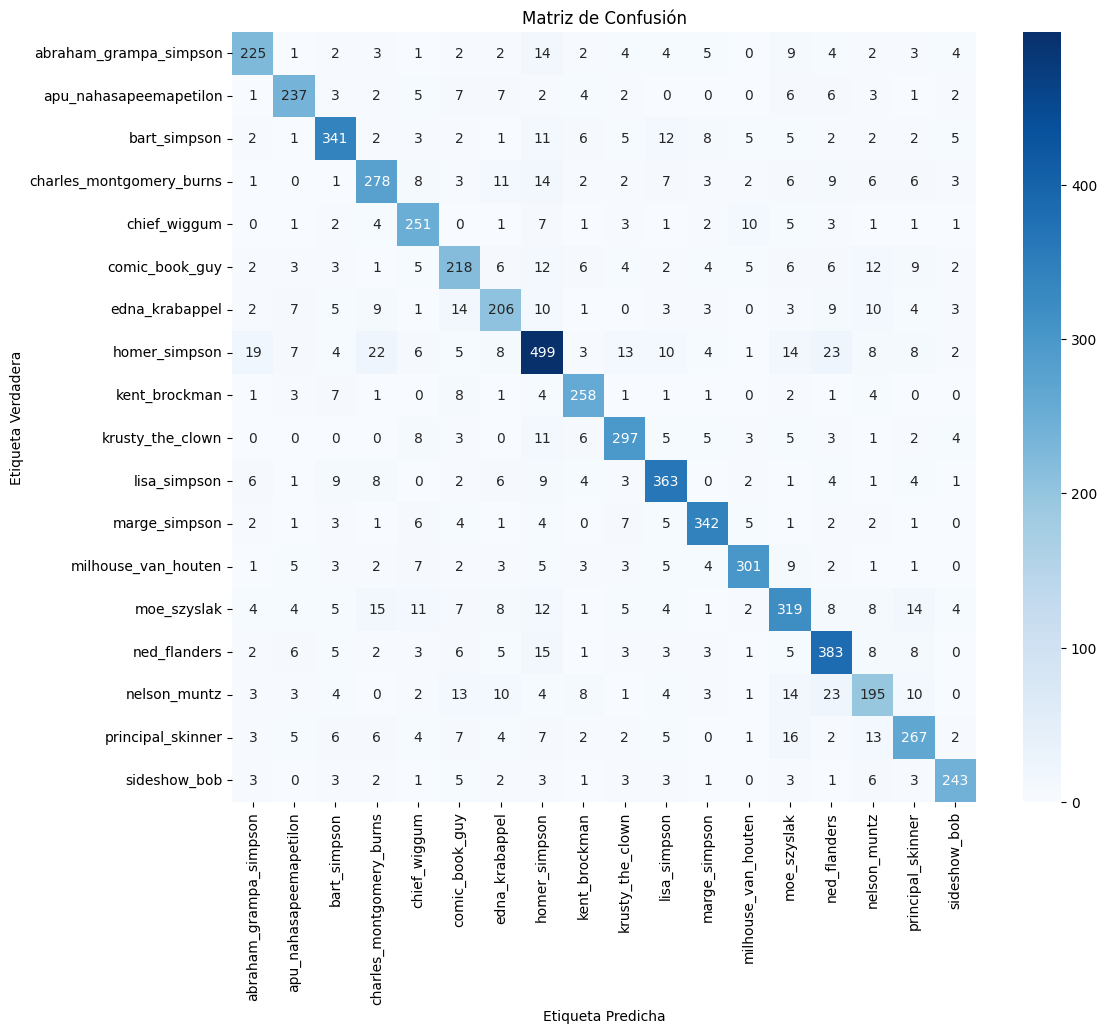

In [ ]:
# prompt: crea un grafico de matriz de confusion
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test.argmax(axis=1), model.predict(X_test).argmax(axis=1))
import matplotlib.pyplot as plt
import seaborn as sns
# Plot the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=CHARACTERS_NAMES, yticklabels=CHARACTERS_NAMES)
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.show()


## Mejora del modelo (AlexNet)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

red_conv = keras.Sequential()
# Bloque 1
red_conv.add(Conv2D(96, activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3), padding='valid',kernel_size=(11,11), strides= 4, kernel_initializer= 'he_normal'))

red_conv.add(MaxPooling2D(pool_size=(2,2), strides= (2,2),
                              padding= 'valid', data_format= None))


# Bloque 2
red_conv.add(Conv2D(256, kernel_size=(5,5), strides= 1,
                        padding= 'same', activation= 'relu',
                        kernel_initializer= 'he_normal'))

red_conv.add(MaxPooling2D(pool_size=(2,2), strides= (2,2),
                              padding= 'valid', data_format= None))
#Bloque 3 EXTRA
red_conv.add(Conv2D(256, kernel_size=(5,5), strides= 1,
                        padding= 'same', activation= 'relu',
                        kernel_initializer= 'he_normal'))

red_conv.add(MaxPooling2D(pool_size=(2,2), strides= (2,2),
                              padding= 'valid', data_format= None))

# Bloque 4 MEJORA EN BATCHZ
red_conv.add(Conv2D(384, kernel_size=(3,3), strides= 1,
                        padding= 'same', activation= 'relu',
                        kernel_initializer= 'he_normal'))
red_conv.add(Conv2D(512, kernel_size=(3,3), strides= 1,
                        padding= 'same', activation= 'relu',
                        kernel_initializer= 'he_normal'))
red_conv.add(Conv2D(1024, kernel_size=(3,3), strides= 1,
                        padding= 'same', activation= 'relu',
                        kernel_initializer= 'he_normal'))
red_conv.add(MaxPooling2D(pool_size=(2,2), strides= (2,2),
                              padding= 'valid', data_format= None))

# Clasificador
red_conv.add(Flatten())
red_conv.add(Dense(4096, activation= 'mish'))
red_conv.add(Dense(4096, activation= 'mish'))
red_conv.add(Dense(1000, activation= 'mish'))
red_conv.add(Dense(18, activation= 'softmax'))

red_conv.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 22, 22, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 256)      │     1,638,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 512)      │     1,769,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 2, 1024)     │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │     4,097,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 18)             │        18,018 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,757,706 (132.59 MB)

 Trainable params: 34,757,706 (132.59 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import datetime
from tensorflow.keras.optimizers import Adam
log_dir="./logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)#Mejora
RLeaning = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1)#Mejora
callback_list = [tensorboard_callback, early,RLeaning]
red_conv.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(0.00001),#Mejora
    metrics=['accuracy'],
)

hist = red_conv.fit(
    X_train,y_train,
    batch_size=32,
    epochs=25,
    validation_data=(X_test,y_test),
    callbacks=callback_list
)

Epoch 1/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.1434 - loss: 2.7313 - val_accuracy: 0.2860 - val_loss: 2.2944 - learning_rate: 1.0000e-05
Epoch 2/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.3726 - loss: 2.0924 - val_accuracy: 0.4064 - val_loss: 1.9792 - learning_rate: 1.0000e-05
Epoch 3/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.4552 - loss: 1.8440 - val_accuracy: 0.4478 - val_loss: 1.8366 - learning_rate: 1.0000e-05
Epoch 4/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.5171 - loss: 1.6208 - val_accuracy: 0.5240 - val_loss: 1.6280 - learning_rate: 1.0000e-05
Epoch 5/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.5644 - loss: 1.4490 - val_accuracy: 0.5575 - val_loss: 1.4841 - learning_rate: 1.0000e-05
Epoch 6/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.6153 - loss: 1.2752 - val_accuracy: 0.5932 - val_loss: 1.3995 - learning_rate: 1.0000e-05
Epoch 7/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/ste

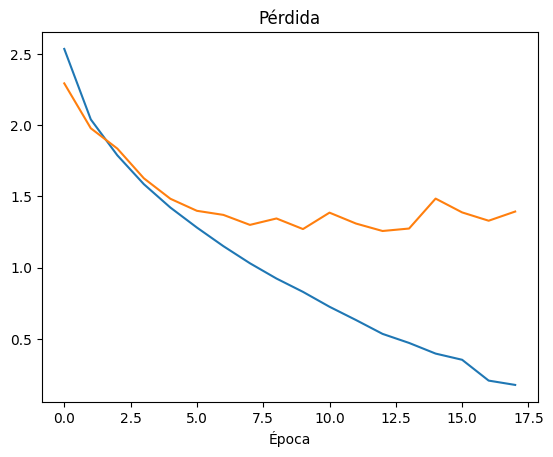

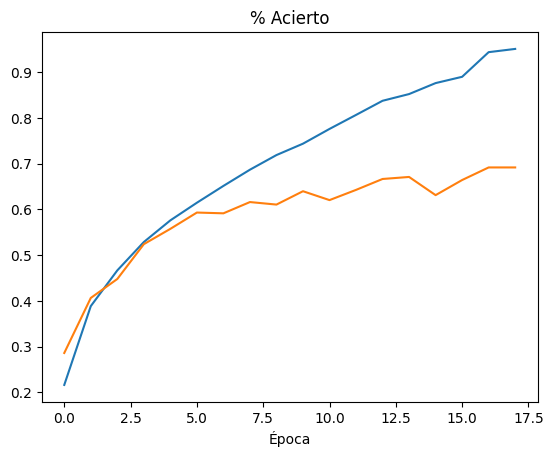

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

In [ ]:
report_dict = classification_report(y_test.argmax(axis=1), red_conv.predict(X_test).argmax(axis=1), target_names=CHARACTERS_NAMES)

205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


In [ ]:
print (report_dict)

                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.53      0.68      0.59       273
  apu_nahasapeemapetilon       0.85      0.72      0.78       305
            bart_simpson       0.45      0.63      0.53       406
charles_montgomery_burns       0.52      0.59      0.55       355
            chief_wiggum       0.84      0.77      0.81       316
          comic_book_guy       0.76      0.59      0.66       309
          edna_krabappel       0.81      0.57      0.67       294
           homer_simpson       0.79      0.53      0.63       699
           kent_brockman       0.68      0.84      0.75       291
        krusty_the_clown       0.80      0.78      0.79       366
            lisa_simpson       0.63      0.50      0.56       420
           marge_simpson       0.74      0.84      0.79       348
     milhouse_van_houten       0.72      0.71      0.71       338
             moe_szyslak       0.51      0.79      0.62       441
         

# CONCLUSION

El trabajo realizado muestra un enfoque sólido y progresivo en el diseño, entrenamiento y evaluación de una red neuronal convolucional, comenzando con una arquitectura base y finalizando con una versión mejorada inspirada en AlexNet. A lo largo del proceso, se aplicaron técnicas clave como normalización, dropout, batch normalization, ajuste de hiperparámetros y uso de callbacks como lo es EarlyStopping, lo que demuestra una comprensión práctica de las buenas prácticas en deep learning.

El desempeño del modelo mejorado, con múltiples bloques convolucionales, capas densas profundas y activaciones avanzadas como mish permitió mejorar la precisión en la clasificación, tal como se evidencia en las curvas de pérdida y precisión, así como en la matriz de confusión y el classification report. No obstante, la matriz muestra que aún hay personajes cuya clasificación presenta más dificultades, probablemente debido a similitudes visuales o desequilibrio en los datos.

El modelo seleccionado finalmente es el modelo con arquitectura Inception V3, ya que es capaz de ser el modelo mas constante y optimo para la comprension de los datos.

**Posibles Mejoras Futuras**

Transfer Learning: Probar arquitecturas preentrenadas como MobileNetV2, ResNet o EfficientNet puede ofrecer mejoras significativas en rendimiento con menos entrenamiento desde cero.

Evaluación con métricas adicionales: Incorporar métricas como F1-score macro y weighted o AUC puede ayudar a comprender mejor el comportamiento del modelo frente a clases minoritarias.

Optimización adicional: La arquitectura mejorada es bastante profunda; aplicar búsqueda de hiperparámetros (con herramientas como Keras Tuner o Optuna) podría afinar aún más la configuración.

